# Recurrent Neural Networks (RNNs)-The Architecture of Memory

### **The Problem with "Memory-less" Networks**
* Standard Neural Networks (MLPs, CNNs) are "memory-less."

* They process every input independently.

* This is a problem when context matters.

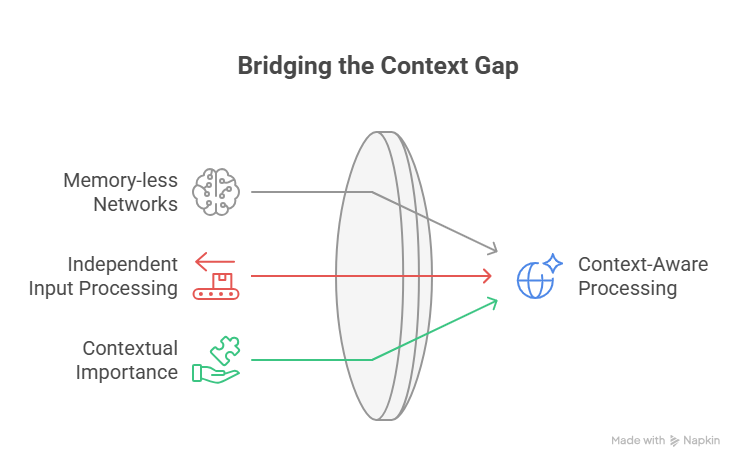

# How would a network understand the word "happy" in these two sentences?

1. "The weather is great. I feel happy." (Positive)

2. "My flight was cancelled. I am not happy." (Negative)

**A standard network would see "happy" the exact same way in both, missing the crucial context of "not."**



# The Solution: Recurrent Neural Networks (RNNs)

* RNNs are a special class of neural network designed specifically for **sequential data (text, time series, audio)**.

* Their defining feature is **MEMORY**.

* An RNN **processes a sequence one element at a time, and the output for the current element is influenced by all the elements that came before it.**

* It **"remembers" past information and uses it to inform the present**.

# How an RNN "Remembers": The **Hidden State**

* RNNs maintain an internal "memory" called the Hidden State (often labeled 'h').

* The Hidden State is a vector of numbers **that summarizes the important information from all previous steps**.

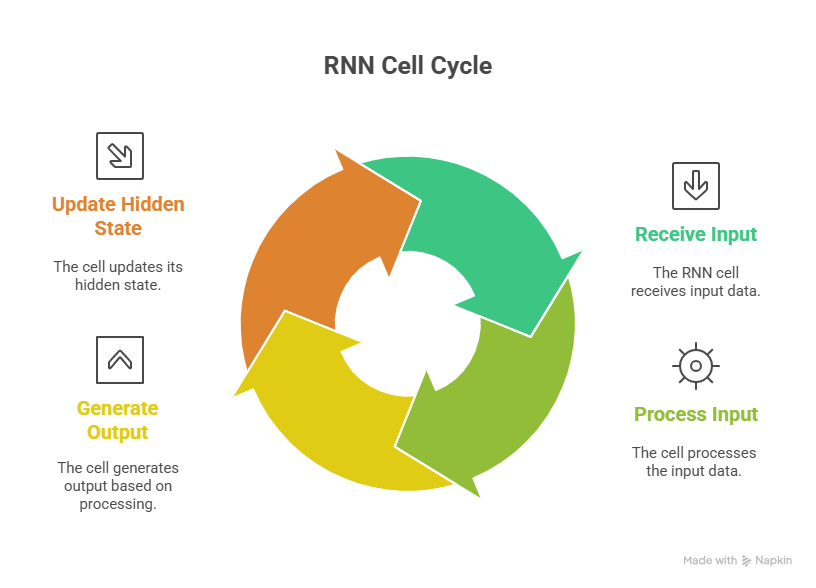

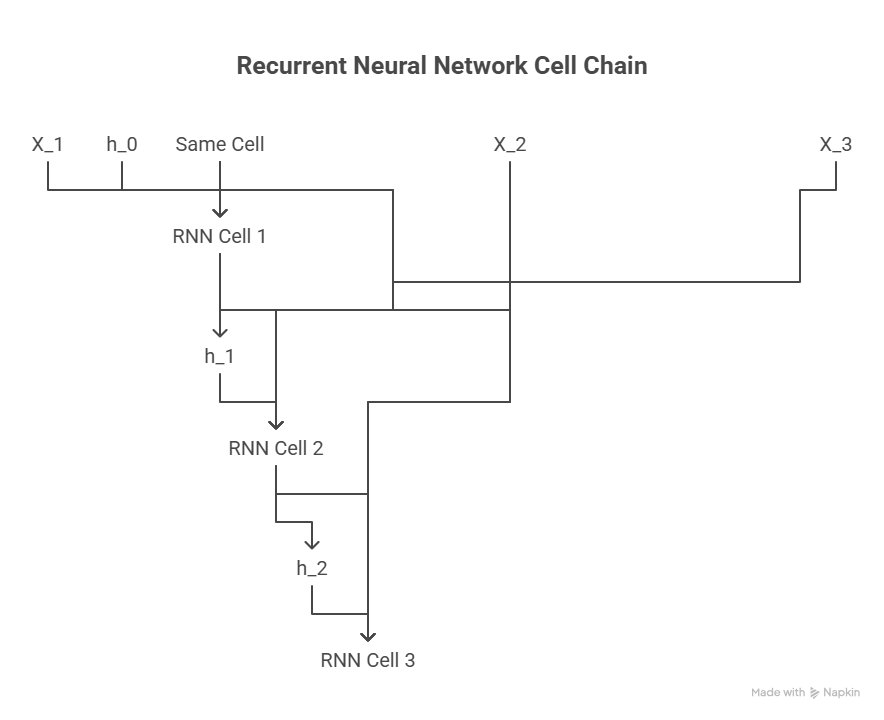

# The Challenge: Long-Term Dependencies
* RNNs work well when context is local.

  * Example: "The clouds are in the sky." (Easy)

* They struggle when context is far apart.

  * Example: "I was born and raised in France... (10 paragraphs of text)... therefore, I speak fluent French."

* This is a Long-Term Dependency.

* The gradient (information) from "France" has to travel all the way through the unrolled chain to help predict "French."

# Long Short Term Memory
* Captures **long-term dependencies in sequential data** making them ideal for tasks like language translation, speech recognition and time series forecasting.

* Traditional RNNs which use a single hidden state passed through time **LSTMs introduce a memory cell** that **holds information over extended periods** addressing the challenge of **learning long-term dependencies**.


# LSTM Architecture
Involves the **memory cell** which is **controlled by three gates**:
1. **Input gate**: Controls what **information is added** to the memory cell.
2. **Forget gate**: Determines what information is **removed** from the memory cell.
3. **Output gate**: Controls what information is output from the memory cell.


 Allows LSTM networks to **selectively retain or discard information as it flows through the network** which allows them to learn long-term dependencies.

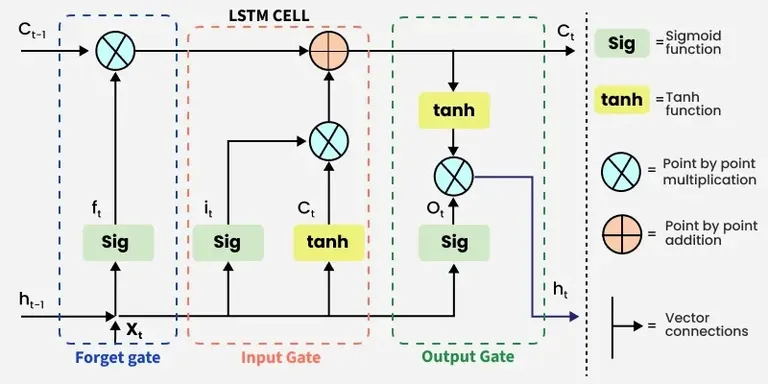

# Forget Gate

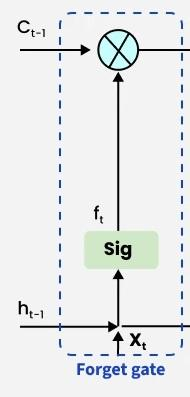

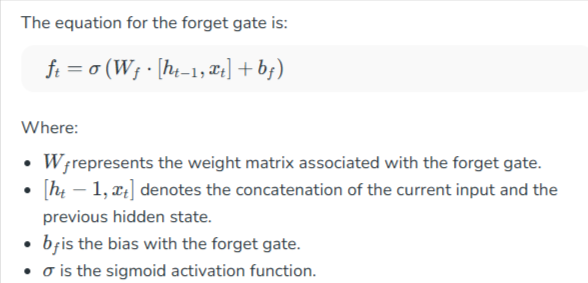

# Input gate
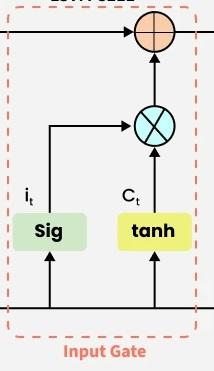

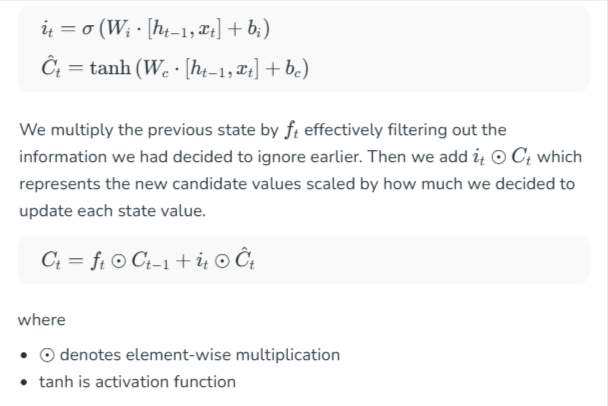

# Output gate
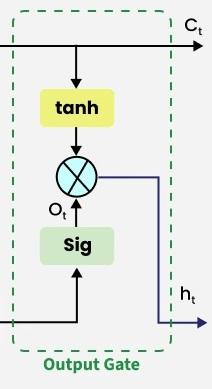

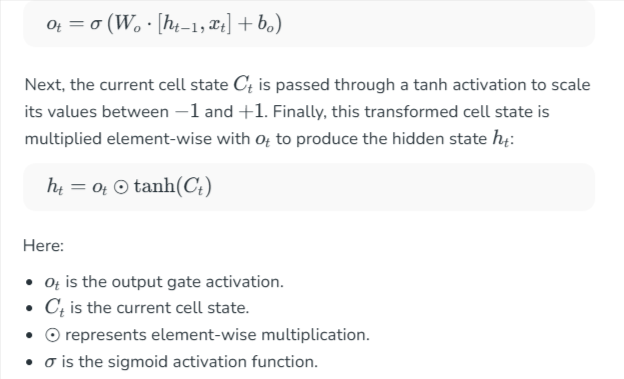

In [ ]:
# ===============================
# COMPARING RNN vs LSTM
# ===============================
!pip install torch matplotlib seaborn --quiet

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
# -----------------------------
# 1. Create a synthetic sequence
# -----------------------------
# Imagine a simple pattern — e.g., "spike" at time step 3
seq_len = 10
batch_size = 1
input_size = 1

x = torch.zeros(seq_len, batch_size, input_size)
x[3] = 1.0  # single spike at position 3

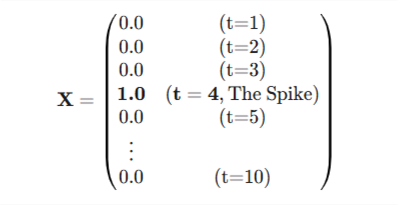

In [ ]:
# -----------------------------
# 2. Define RNN and LSTM
# -----------------------------
hidden_size = 4

rnn = nn.RNN(input_size, hidden_size, nonlinearity='tanh')
lstm = nn.LSTM(input_size, hidden_size) #dimensionality of both the hidden state and the Cell State .

In [ ]:
# -----------------------------
# 3. Forward pass
# -----------------------------
rnn_output, _ = rnn(x)
lstm_output, _ = lstm(x)


In [ ]:
# Convert to numpy for plotting Removes the redundant batch dimension. Since $\mathbf{batch\_size}=1$, this dimension is unnecessary for visualization. Disconnects the tensor from the computation graph.
rnn_output = rnn_output.squeeze(1).detach().numpy()
lstm_output = lstm_output.squeeze(1).detach().numpy()

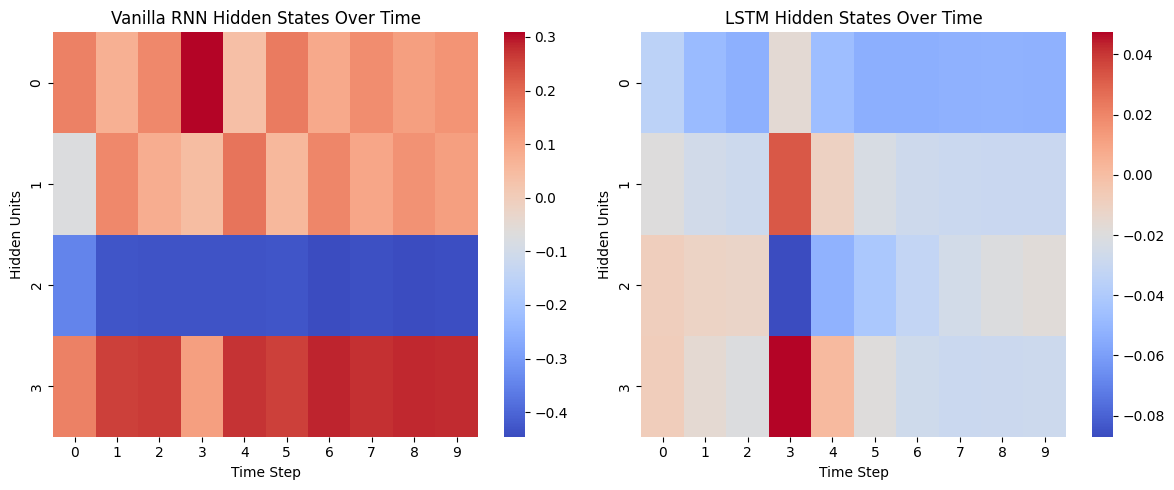

In [ ]:
# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(rnn_output.T, cmap="coolwarm", cbar=True)
plt.title("Vanilla RNN Hidden States Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden Units")

plt.subplot(1,2,2)
sns.heatmap(lstm_output.T, cmap="coolwarm", cbar=True)
plt.title("LSTM Hidden States Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden Units")

plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# 5. Explanation Summary
# -----------------------------
print("💡 Observation:")
print("- RNN activations fade quickly after the spike (short-term memory).")
print("- LSTM maintains stronger activation for several time steps (long-term memory).")
print("- This demonstrates how LSTM's cell state and gating mechanism help retain information.")

💡 Observation:
- RNN activations fade quickly after the spike (short-term memory).
- LSTM maintains stronger activation for several time steps (long-term memory).
- This demonstrates how LSTM's cell state and gating mechanism help retain information.


# Gated Recurrent Units (GRU)

* LSTMs are very complex structure with **higher computational cost**.
* To overcome this Gated Recurrent Unit (GRU) where introduced which uses LSTM architecture by **merging its gating mechanisms** offering a more efficient solution for many sequential tasks without sacrificing performance.


* GRUs aim to **simplify the LSTM architecture** by **merging some of its components and focusing on just two main gates**: the ***update gate and the reset gate***.



### The GRU consists of two main gates:

1. ***Update Gate*** (z<sub>t</sub>): Decides **how much information from previous hidden state should be retained** for the next time step.

2. ***Reset Gate***(r<sub>t</sub>): Determines how much of the past hidden state should be forgotten.


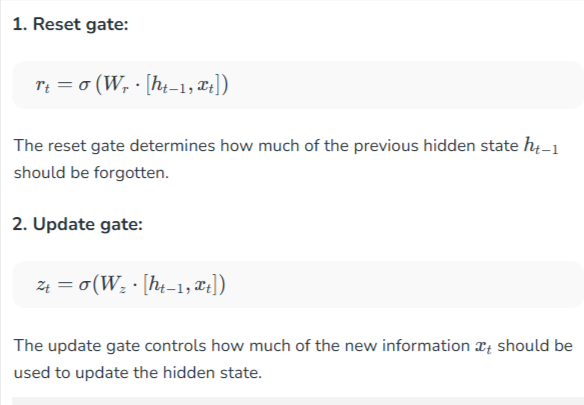

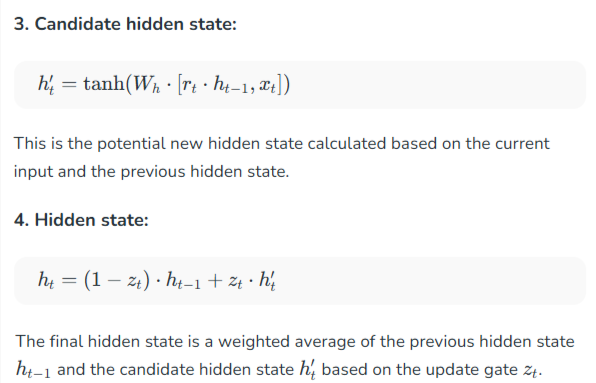